
# <span style="color:rgb(213,80,0)">APROKSYMACJA</span>

## IMPLEMENTACJE APROKSYMACJI

Aproksymacja wielomianowa, o której mówimy może być zaimplementowana na dwa sposoby:


1. Pierwszy sposób polega na tym, że tworzymy macierz nadokreślonego układu równań, którą następnie rozwiązujemy za pomocą metod rozwiązania Liniowego Zadania Najmniejszych Kwadratów


In [1]:
% wytwórzmy przykładowe punkty do obliczenia aproksymacji
N = 20;                % 20 węzłów
M = 10;                % wielomian stopnia 10
xx=linspace(1, 10, N);
fun = @(x) x.^6./exp(x);
yy = fun(xx);

% Uruchommy drugą implementację aproksymacji
[wsp, S] = polyfit(xx,yy,M);       %aproksymujemy za pomocą wielomianu 6 stopnia

%Zanim narysujemy wynik aproksymacji przyjrzyjmy się strukturze S
%Tutaj znajduje się norma residuów w węzłach
fprintf("Implementacja 1\n");

Implementacja 1

In [2]:
fprintf("Norma residuów: %e",S.normr);

Norma residuów: 2.358427e+00


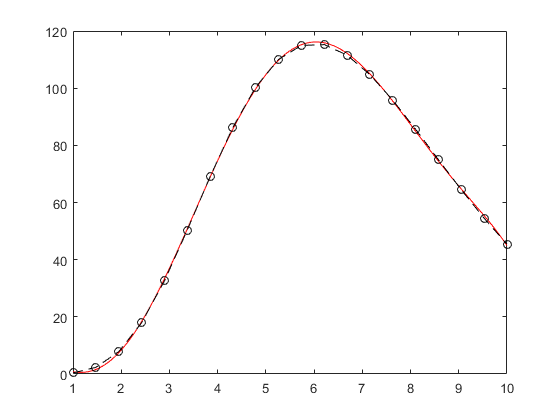

In [3]:

%Wyrysujmy wynik
x=linspace(min(xx), max(xx), 401);
y = polyval(wsp,x);
plot(x, y, 'r', xx,yy,'ko', xx,fun(xx), 'k--')


2. Druga implementacja polega na rozwiązaniu układu równań zbudowanego z iloczynów skalarnych. Realizuje ją poniższy kod \- przyjrzyj się na czym polega istota tej metody


In [4]:
% Uruchommy drugą implementację aproksymacji
[wsp, normr] = dotProductApproximation(xx,yy,M);       %aprksymujemy za pomocą wielomianu 4 stopnia

%Zanim narysujemy wynik aproksymacji przyjrzyjmy się strukturze S
%Tutaj znajduje się norma residuów w węzłach
fprintf("Implementacja 2\n");

Implementacja 2

In [ ]:
fprintf("Norma residuów: %e\n",normr);


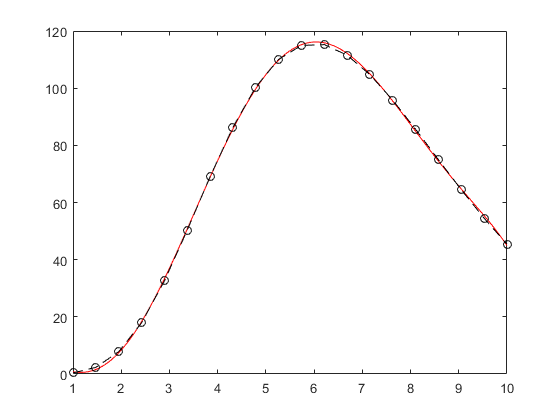

In [6]:

%Wyrysujmy wynik
x=linspace(min(xx), max(xx), 401);
y = polyval(wsp,x);
plot(x, y, 'r', xx,yy,'ko', xx,fun(xx), 'k--')

Pozornie te dwa sposoby są identyczne, ale sposób drugi jest zoptymalizowany pod względem rozwiązania problemu uwarunkowania numerycznego ukłądu równań.


**ĆWICZENIE 1**


Zmień N (np. na 10, 50, 100) oraz M (np. 2, 4, 8) i obserwuj:
- Jak zmienia się norma residuów?
- Kiedy sposób 2 (równania normalne) może dać gorsze wyniki numeryczne niż sposób 1?
- Co się dzieje, gdy M zbliża się do N-1 (przejście w interpolację)?

Podpowiedź: Dla dużych wartości M macierz A=FiT*Fi stanie się słabo uwarunkowana — sprawdź wyznacznik `det(A)`.


**ĆWICZENIE 2**


Na efekt aproksymacji wpływ mają nie tylko właściwości układu równań, ale również właściwości funkcji wewnątrz przediału aproksymacji. Powtórz poprzedni eksperyment dla przedziału \[1,2\]. Sprawdź czy widać znaczne różnice miezy wynikami z ćwiczenia 1 i ćwiczenia 2.

## WYKORZYSTYWANE FUNKCJE

In [8]:
function [wsp, normr, Fi, A] = dotProductApproximation(xx,yy,n)
    N=n+1;
    %Budujemy macierz Fi dla prostej bazy wielomianowej
    for i=1:1:N
        for j=1:1:numel(xx)
            Fi(j,i)=polyval(eye(1,i),xx(j));
        end
    end
    %Obliczamy macierz transponowaną
    FiT = Fi';
    %Obliczamy macierz A ukłądu równań
    A= FiT*Fi;
    %Obliczamy wektor b
    for i=1:1:N
        b(i)=dot(polyval(eye(1,i),xx),yy);
    end
    %Obliczamy rozwiązanie
    wsp = A\b';wsp=flip(wsp);

    normr = norm(polyval(wsp,xx)-yy);
end